In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tifffile import imread
from csbdeep.utils import Path, download_and_extract_zip_file, plot_some
from csbdeep.io import save_tiff_imagej_compatible
from csbdeep.models import CARE
import glob
import os
from lazy5.inspect import get_attrs_dset
import numpy as np
import matplotlib.pyplot as plt
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some

I0000 00:00:1779060000.915254    6477 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779060001.494760    6477 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779060004.500324    6477 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
DATA_FOLDER = "./data_simulated/test/test"
DATA_KEY = "Z_noisy"  # options: 'Z_noisy', 'noisy_bcars', 'bcars_noise_free'

npz_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.npz")))
print(f"Found {len(npz_files)} NPZ file(s):")
for p in npz_files:
    print(f"  {os.path.basename(p)}")

Found 5 NPZ file(s):
  bcars_batched_fit_2026-05-07_16-53-00_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_03_PROCESS_202657_14_31_2_680773_PROCESS_202657_14_55_18_272376_tolerance=1e-05_with_Znoisy.npz
  bcars_batched_fit_2026-05-07_17-26-16_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_05_PROCESS_202657_14_45_24_362743_PROCESS_202657_14_58_5_69804_tolerance=1e-05_with_Znoisy.npz
  bcars_batched_fit_2026-05-07_18-44-33_preprocessed_medfilter_20250508_celegans_l4_04_PROCESS_202657_15_53_21_789216_tolerance=1e-05_with_Znoisy.npz
  bcars_batched_fit_2026-05-07_19-06-15_preprocessed_medfilter_20250508_celegans_l4_05_PROCESS_202657_15_50_34_914587_tolerance=1e-05_with_Znoisy.npz
  bcars_batched_fit_2026-05-07_19-18-00_preprocessed_medfilter_20250508_celegans_l4_06_PROCESS_202657_16_9_41_390866_tolerance=1e-05_with_Znoisy.npz


In [3]:
npz_path = npz_files[1]  # change index to select a different file
with np.load(npz_path) as f:
    print(f"Keys in {os.path.basename(npz_path)}: {f.files}")
    arr = f[DATA_KEY].astype(np.float32)  # (ny, nx, n_wn)

print(f"Loaded '{DATA_KEY}' shape: {arr.shape}  (ny, nx, n_wn)")

Keys in bcars_batched_fit_2026-05-07_17-26-16_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_05_PROCESS_202657_14_45_24_362743_PROCESS_202657_14_58_5_69804_tolerance=1e-05_with_Znoisy.npz: ['processed_spectrum', 'dispersive_spectrum', 'unprocessed_spectrum', 'x_axis', 'wn_axis', 'bcars_noise_free', 'noisy_bcars', 'Z_noisy', 'nrb_amp_normed']
Loaded 'Z_noisy' shape: (320, 500, 695)  (ny, nx, n_wn)


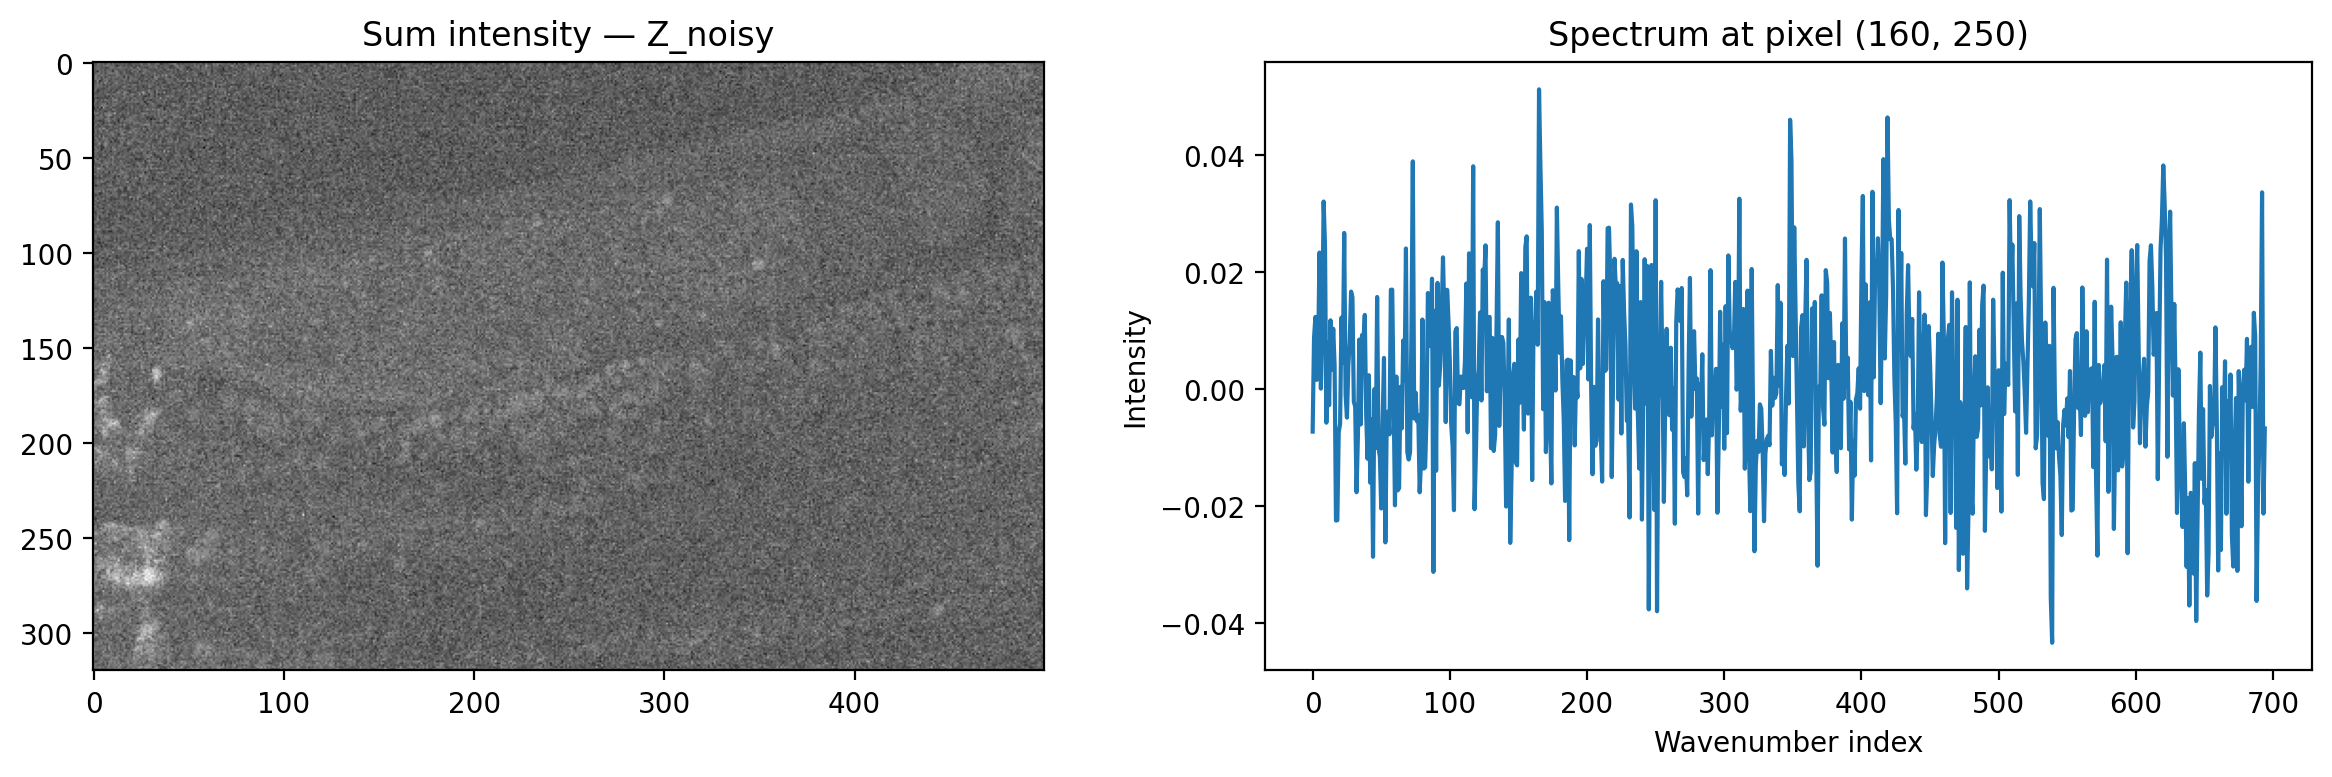

In [4]:
ny, nx, n_wn = arr.shape
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(arr.sum(axis=2), cmap='gray')
axs[0].set_title(f'Sum intensity — {DATA_KEY}')

cy, cx = ny // 2, nx // 2
axs[1].plot(arr[cy, cx, :])
axs[1].set_xlabel('Wavenumber index')
axs[1].set_ylabel('Intensity')
axs[1].set_title(f'Spectrum at pixel ({cy}, {cx})')

plt.tight_layout()
plt.show()

In [5]:
# (ny, nx, n_wn) → (n_wn, ny, nx)  =  ZYX  for CARE
x = arr.transpose(2, 0, 1)
axes = 'ZYX'
print(f"Model input: shape={x.shape}, axes={axes}")

Model input: shape=(695, 320, 500), axes=ZYX


In [6]:
model = CARE(config=None, name='wpermute_model_4layers_20260513', basedir='models')

W0000 00:00:1779060013.727535    6477 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779060013.727708    6477 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779060014.020052    6477 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779060014.020099    6477 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779060014.104876    6477 gpu_device.cc:2040] Create

Loading network weights from 'weights_best.h5'.


In [7]:
restored = model.predict(x, axes, n_tiles=(16,4,4))

I0000 00:00:1779060018.626042    6782 service.cc:158] XLA service 0x72a37400a270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779060018.626101    6782 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1779060018.626106    6782 service.cc:166]   StreamExecutor device (1): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1779060018.661088    6782 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779060018.770609    6782 cuda_dnn.cc:463] Loaded cuDNN version 91002
E0000 00:00:1779060021.689900    6921 slow_operation_alarm.cc:73] Trying algorithm eng33{k2=2,k6=1,k13=2,k14=0,k22=1} for conv (f32[1,32,224,224,272]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,224,224,272]{4,3,2,1,0}, f32[32,32,3,3,3]{4,3,2,1,0}, f32[32]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, cust

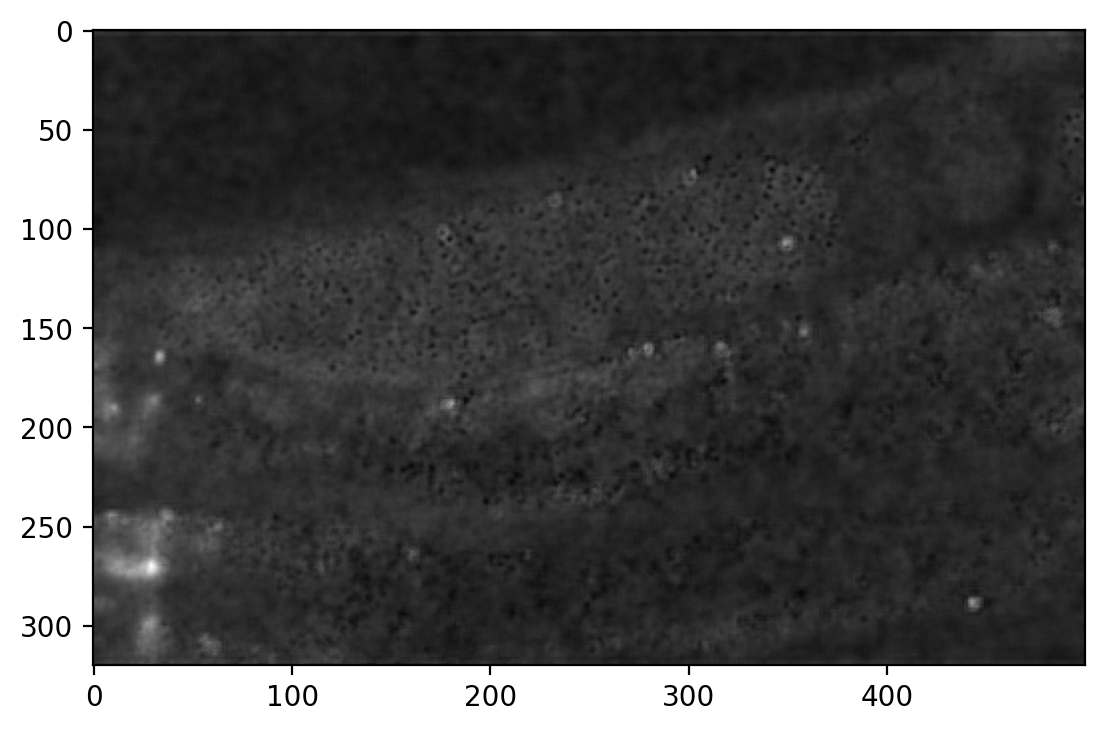

In [8]:
plt.imshow(np.sum(restored, axis=0), cmap='gray')

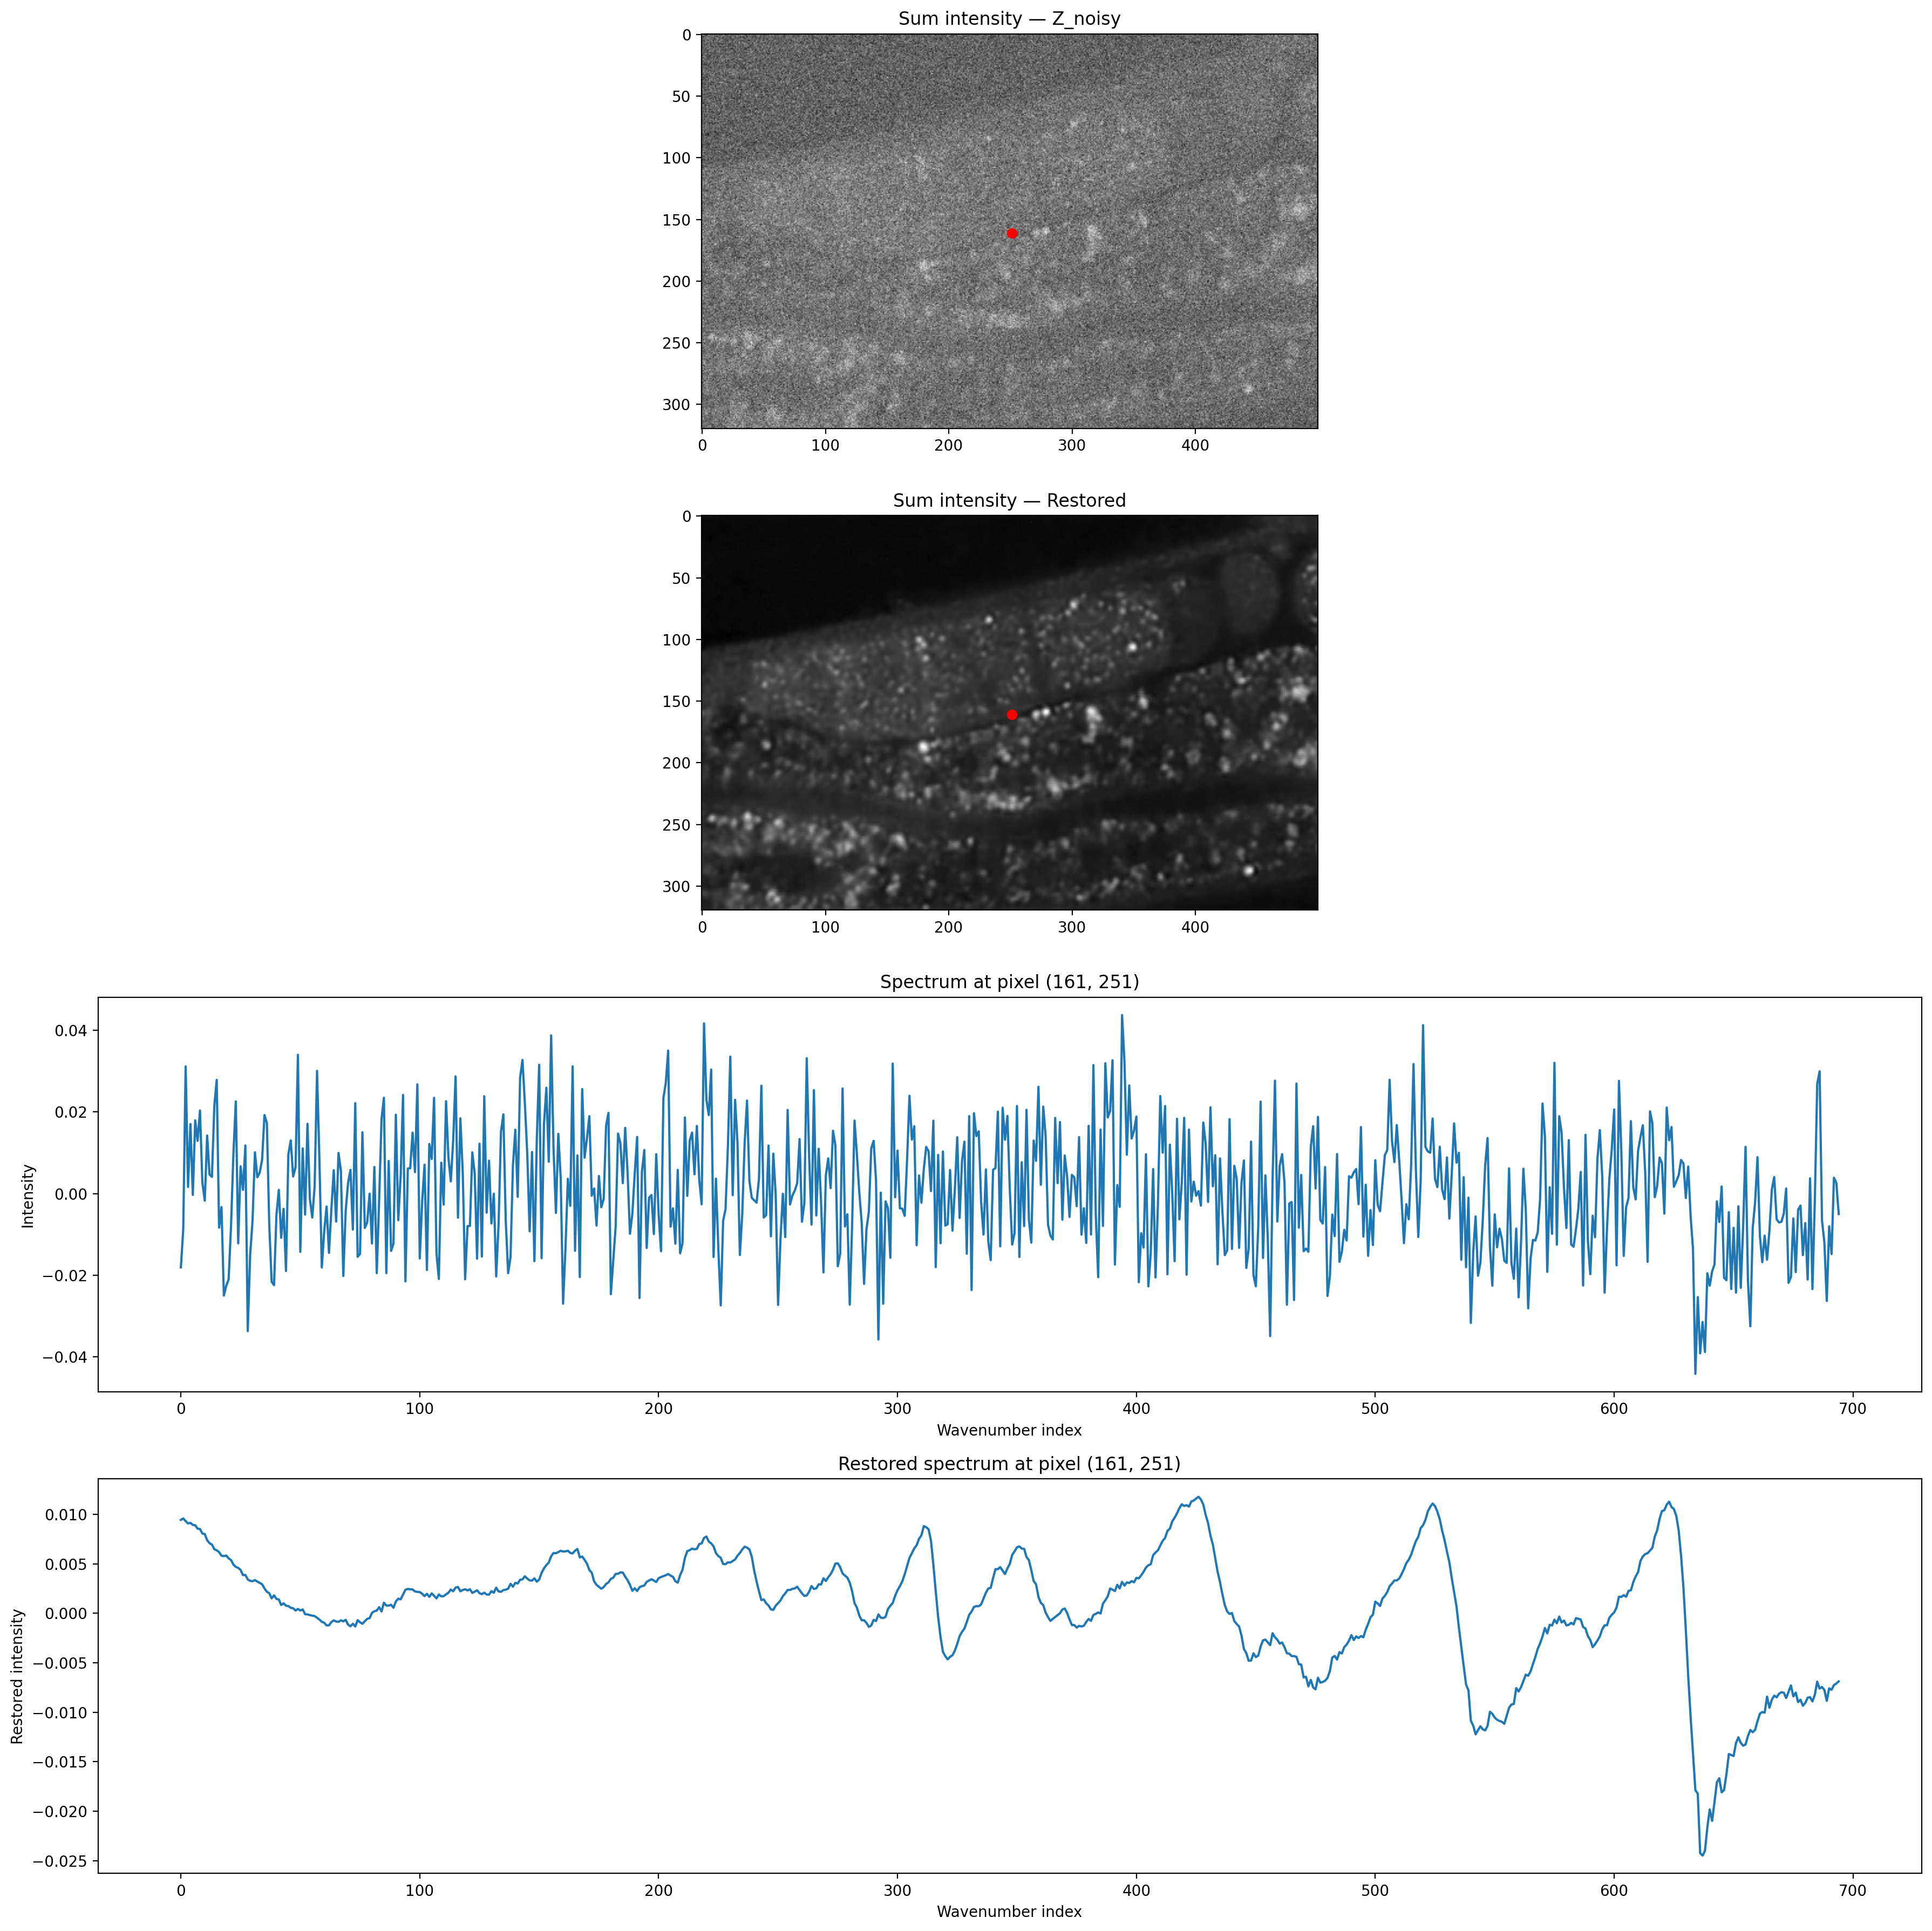

In [9]:
ny, nx, n_wn = arr.shape
fig, axs = plt.subplots(4, 1, figsize=(18, 18))
cy, cx = ny // 2 + 1, nx // 2 + 1

axs[0].imshow(arr[:,:,520], cmap='gray')
axs[0].set_title(f'Sum intensity — {DATA_KEY}')
axs[0].plot(cx, cy, 'ro')

axs[1].imshow(restored[520,:,:], cmap='gray')
axs[1].set_title('Sum intensity — Restored')
axs[1].plot(cx, cy, 'ro')

axs[2].plot(arr[cy, cx, :])
axs[2].set_xlabel('Wavenumber index')
axs[2].set_ylabel('Intensity')
axs[2].set_title(f'Spectrum at pixel ({cy}, {cx})')

axs[3].plot(restored[:, cy, cx])
axs[3].set_xlabel('Wavenumber index')
axs[3].set_ylabel('Restored intensity')
axs[3].set_title(f'Restored spectrum at pixel ({cy}, {cx})')



plt.tight_layout()
plt.show()

In [10]:
with np.load(npz_path) as f:
    bcars_nf = f['bcars_noise_free'].astype(np.float32)  # (ny, nx, n_wn)
    nrb      = f['nrb_amp_normed'].astype(np.float32)    # (ny, nx, n_wn)

Z_noise_free = (bcars_nf - nrb**2) / (2 * nrb)  # same formula as Z_noisy
x_nf = Z_noise_free.transpose(2, 0, 1)           # (n_wn, ny, nx) = ZYX
print(f"Z_noise_free shape: {x_nf.shape}")

Z_noise_free shape: (695, 320, 500)


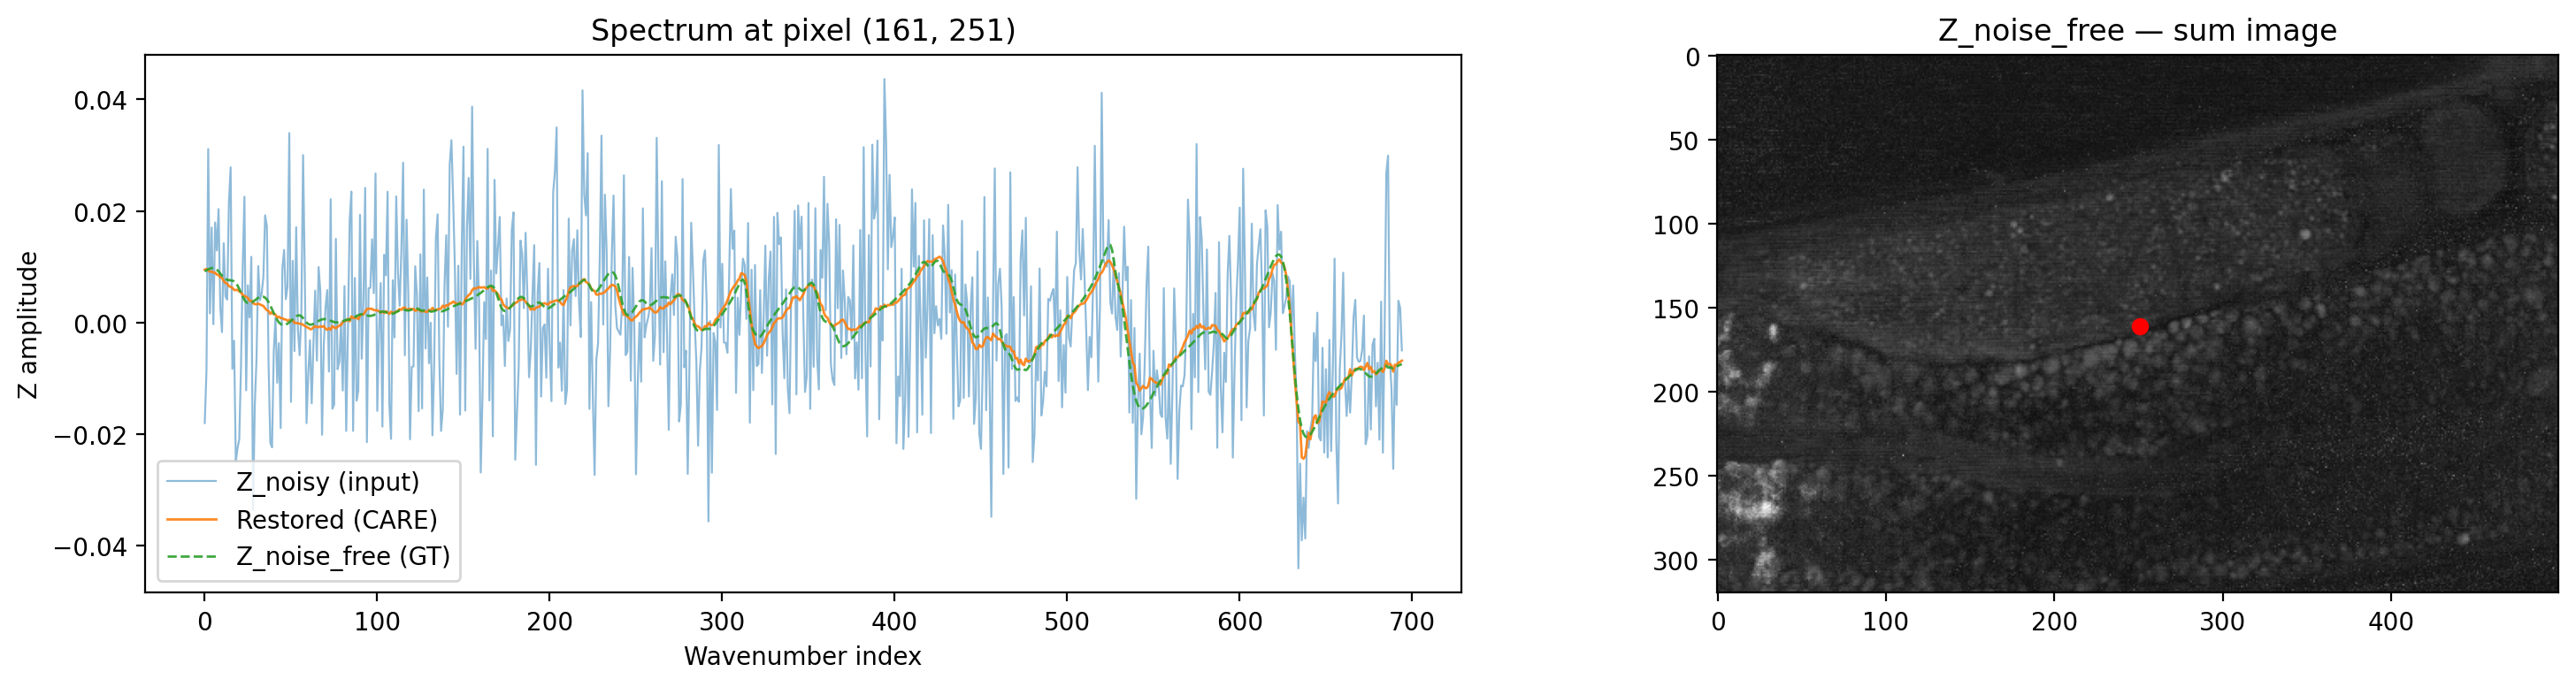

PSNR (restored vs Z_noise_free): 40.75 dB


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# --- spectrum comparison at sample pixel ---
axs[0].plot(x[:, cy, cx],    label='Z_noisy (input)',       alpha=0.5, linewidth=0.8)
axs[0].plot(restored[:, cy, cx], label='Restored (CARE)',   alpha=0.9, linewidth=1.0)
axs[0].plot(x_nf[:, cy, cx], label='Z_noise_free (GT)',     alpha=0.9, linewidth=1.0, linestyle='--')
axs[0].set_xlabel('Wavenumber index')
axs[0].set_ylabel('Z amplitude')
axs[0].set_title(f'Spectrum at pixel ({cy}, {cx})')
axs[0].legend()

# --- sum-image comparison ---
axs[1].imshow(np.sum(x_nf, axis=0), cmap='gray')
axs[1].set_title('Z_noise_free — sum image')
axs[1].plot(cx, cy, 'ro')

plt.tight_layout()
plt.show()

# --- PSNR: restored vs noise-free ---
mse = np.mean((restored - x_nf) ** 2)
data_range = x_nf.max() - x_nf.min()
if mse > 0:
    psnr = 20 * np.log10(data_range / np.sqrt(mse))
    print(f"PSNR (restored vs Z_noise_free): {psnr:.2f} dB")
else:
    print("MSE = 0, perfect reconstruction")

In [14]:
from SVD import SVDDecompose, SVDRecompose

# SVD operates on arr (ny, nx, n_wn) — internally flattened to (ny*nx, n_wn)
# May take a minute for 320x500x695
svd_decompose = SVDDecompose()
U, s, Vh = svd_decompose.calculate(arr)
print(f"U:{U.shape}  s:{s.shape}  Vh:{Vh.shape}")

n_svs = 10 # number of singular values to keep — adjust to taste
svs = np.arange(n_svs)
reconstructed = np.dot(U[:, svs], s[svs, None] * Vh[svs, :])
x_svd = reconstructed.reshape(arr.shape).transpose(2, 0, 1)  # (n_wn, ny, nx) = ZYX
print(f"SVD denoised shape: {x_svd.shape}  (n_svs={n_svs})")

U:(160000, 695)  s:(695,)  Vh:(695, 695)
SVD denoised shape: (695, 320, 500)  (n_svs=10)


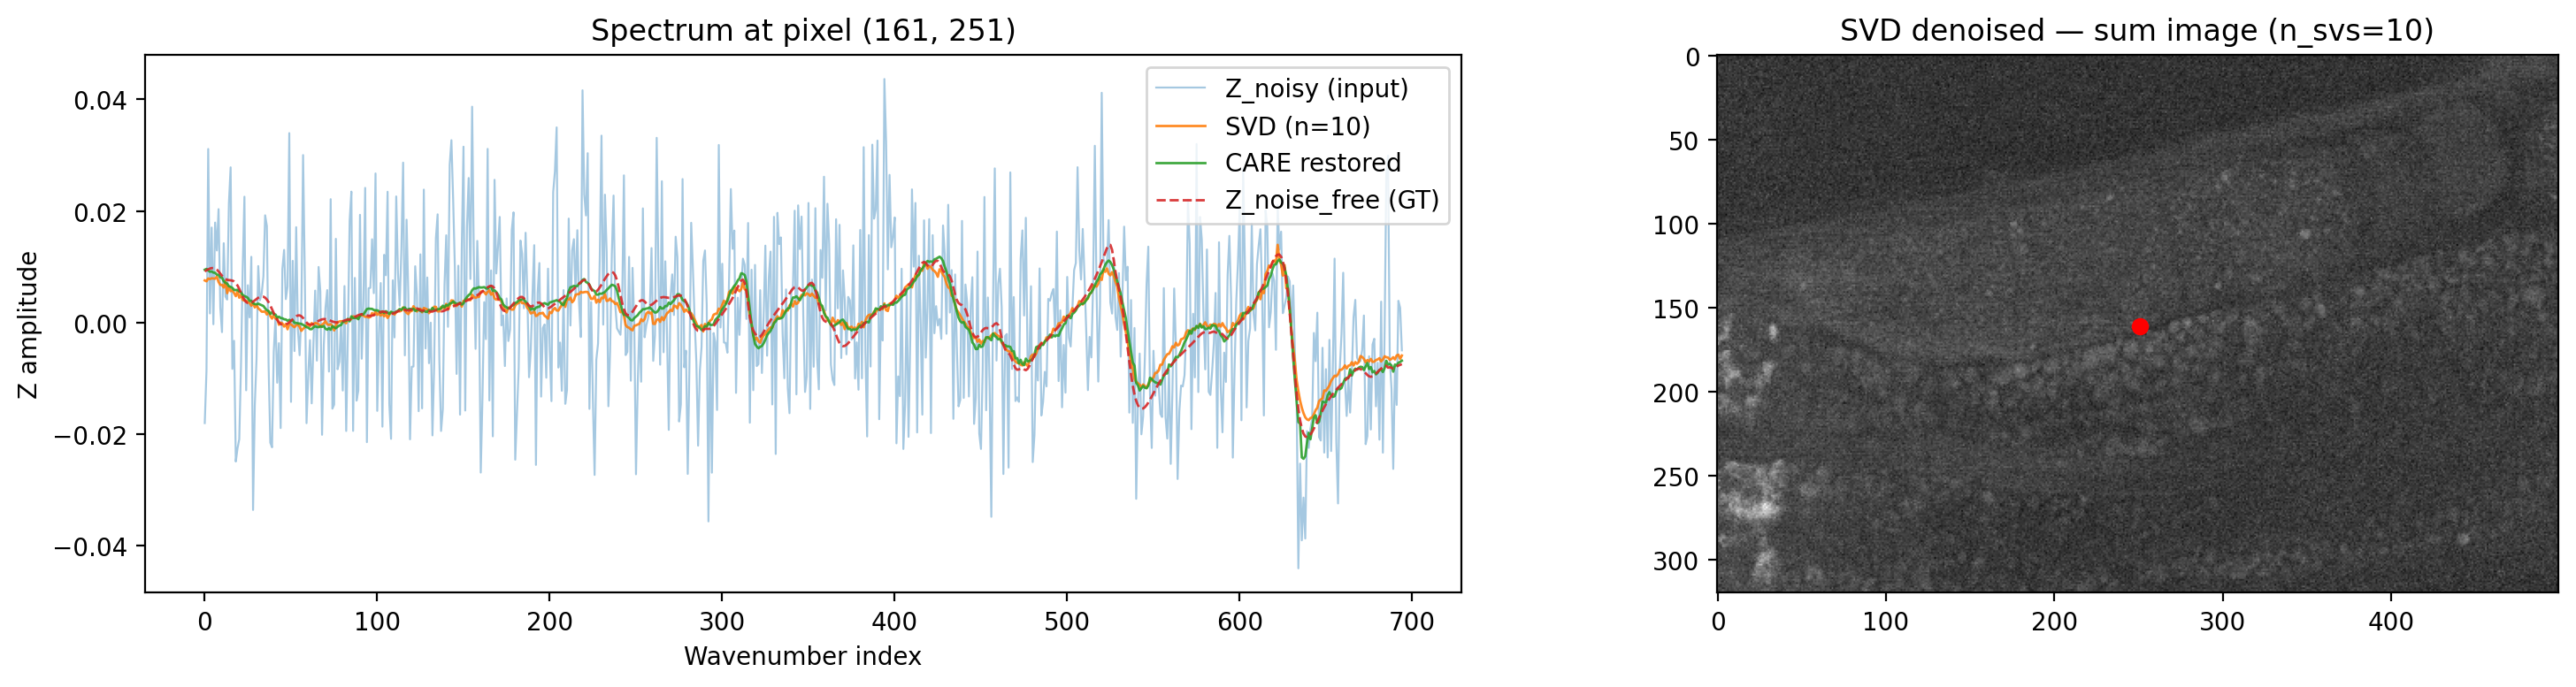

PSNR          Noisy input: 20.03 dB
PSNR           SVD (n=10): 37.85 dB
PSNR        CARE restored: 40.75 dB


In [15]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

# --- spectrum comparison ---
axs[0].plot(x[:, cy, cx],        label='Z_noisy (input)',       alpha=0.4, linewidth=0.8)
axs[0].plot(x_svd[:, cy, cx],    label=f'SVD (n={n_svs})',      alpha=0.9, linewidth=1.0)
axs[0].plot(restored[:, cy, cx], label='CARE restored',         alpha=0.9, linewidth=1.0)
axs[0].plot(x_nf[:, cy, cx],     label='Z_noise_free (GT)',     alpha=0.9, linewidth=1.0, linestyle='--')
axs[0].set_xlabel('Wavenumber index')
axs[0].set_ylabel('Z amplitude')
axs[0].set_title(f'Spectrum at pixel ({cy}, {cx})')
axs[0].legend()

# --- sum image: SVD denoised ---
axs[1].imshow(np.sum(x_svd, axis=0), cmap='gray')
axs[1].set_title(f'SVD denoised — sum image (n_svs={n_svs})')
axs[1].plot(cx, cy, 'ro')

plt.tight_layout()
plt.show()

# --- PSNR for both methods vs noise-free ---
data_range = x_nf.max() - x_nf.min()

mse_care = np.mean((restored - x_nf) ** 2)
mse_svd  = np.mean((x_svd    - x_nf) ** 2)
mse_noisy = np.mean((x       - x_nf) ** 2)

for label, mse in [('Noisy input', mse_noisy), (f'SVD (n={n_svs})', mse_svd), ('CARE restored', mse_care)]:
    psnr = 20 * np.log10(data_range / np.sqrt(mse)) if mse > 0 else float('inf')
    print(f"PSNR {label:>20s}: {psnr:.2f} dB")

In [16]:
import os
import numpy as np
import glob

for npz_path in npz_files:
    print(f"Processing: {os.path.basename(npz_path)}")

    with np.load(npz_path) as f:
        arr = f['Z_noisy'].astype(np.float32)  # (ny, nx, n_wn)

    x = arr.transpose(2, 0, 1)  # (n_wn, ny, nx) = ZYX
    restored = model.predict(x, 'ZYX', n_tiles=(16, 4, 4))

    out_name = 'n2n_restored_' + os.path.basename(npz_path)
    out_path = os.path.join(os.path.dirname(npz_path), out_name)
    np.savez(out_path, restored=restored)
    print(f"  Saved -> {out_name}")

print("Done.")

Processing: bcars_batched_fit_2026-05-07_16-53-00_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_03_PROCESS_202657_14_31_2_680773_PROCESS_202657_14_55_18_272376_tolerance=1e-05_with_Znoisy.npz


100%|██████████| 256/256 [02:41<00:00,  1.58it/s] 


  Saved -> n2n_restored_bcars_batched_fit_2026-05-07_16-53-00_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_03_PROCESS_202657_14_31_2_680773_PROCESS_202657_14_55_18_272376_tolerance=1e-05_with_Znoisy.npz
Processing: bcars_batched_fit_2026-05-07_17-26-16_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_05_PROCESS_202657_14_45_24_362743_PROCESS_202657_14_58_5_69804_tolerance=1e-05_with_Znoisy.npz


100%|██████████| 256/256 [02:43<00:00,  1.57it/s]  


  Saved -> n2n_restored_bcars_batched_fit_2026-05-07_17-26-16_preprocessed_medfilter_05072025_NR_dhs-3-gfp_AD_05_PROCESS_202657_14_45_24_362743_PROCESS_202657_14_58_5_69804_tolerance=1e-05_with_Znoisy.npz
Processing: bcars_batched_fit_2026-05-07_18-44-33_preprocessed_medfilter_20250508_celegans_l4_04_PROCESS_202657_15_53_21_789216_tolerance=1e-05_with_Znoisy.npz


...

  Saved -> n2n_restored_bcars_batched_fit_2026-05-07_18-44-33_preprocessed_medfilter_20250508_celegans_l4_04_PROCESS_202657_15_53_21_789216_tolerance=1e-05_with_Znoisy.npz
Processing: bcars_batched_fit_2026-05-07_19-06-15_preprocessed_medfilter_20250508_celegans_l4_05_PROCESS_202657_15_50_34_914587_tolerance=1e-05_with_Znoisy.npz


E0000 00:00:1779069781.904734    6921 slow_operation_alarm.cc:73] Trying algorithm eng33{k2=15,k6=2,k13=1,k14=0,k22=0} for conv (f32[1,32,224,208,272]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,224,208,272]{4,3,2,1,0}, f32[32,32,3,3,3]{4,3,2,1,0}, f32[32]{0}), window={size=3x3x3 pad=1_1x1_1x1_1}, dim_labels=bf012_oi012->bf012, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} is taking a while...
E0000 00:00:1779069782.043829    6784 slow_operation_alarm.cc:140] The operation took 1.139231458s
Trying algorithm eng33{k2=15,k6=2,k13=1,k14=0,k22=0} for conv (f32[1,32,224,208,272]{4,3,2,1,0}, u8[0]{0}) custom-call(f32[1,32,224,208,272]{4,3,2,1,0}, f32[32,32,3,3,3]{4,3,2,1,0}, f32[32]{0}), window={size=3x3x3 

  Saved -> n2n_restored_bcars_batched_fit_2026-05-07_19-06-15_preprocessed_medfilter_20250508_celegans_l4_05_PROCESS_202657_15_50_34_914587_tolerance=1e-05_with_Znoisy.npz
Processing: bcars_batched_fit_2026-05-07_19-18-00_preprocessed_medfilter_20250508_celegans_l4_06_PROCESS_202657_16_9_41_390866_tolerance=1e-05_with_Znoisy.npz


100%|██████████| 256/256 [02:06<00:00,  2.03it/s]  


  Saved -> n2n_restored_bcars_batched_fit_2026-05-07_19-18-00_preprocessed_medfilter_20250508_celegans_l4_06_PROCESS_202657_16_9_41_390866_tolerance=1e-05_with_Znoisy.npz
Done.
